In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\lenovo\Downloads\DADS\July_18th&19th\Files_19th\Python_Project\retail_sales_dataset.csv')
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,11/24/2023,CUST001,Male,34.0,Beauty,3.0,50.0,150
1,2,2/27/2023,CUST002,Female,26.0,Clothing,2.0,500.0,1000
2,3,1/13/2023,CUST003,Male,50.0,Electronics,1.0,30.0,30
3,4,5/21/2023,CUST004,Male,37.0,Clothing,1.0,500.0,500
4,5,5/6/2023,CUST005,Male,30.0,Beauty,2.0,50.0,100
5,6,4/25/2023,CUST006,Female,45.0,NaN,1.0,30.0,30
6,7,3/13/2023,CUST007,Male,46.0,Clothing,2.0,25.0,50
7,8,2/22/2023,CUST008,Male,30.0,Electronics,4.0,25.0,100
8,9,12/13/2023,CUST009,Male,63.0,Electronics,2.0,300.0,600
9,10,10/7/2023,CUST010,Female,52.0,Clothing,4.0,50.0,200


In [3]:
print("The info of data and null value information is as below", "\n")
df.info()

The info of data and null value information is as below 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    1000 non-null   int64  
 1   Date              1000 non-null   object 
 2   Customer ID       1000 non-null   object 
 3   Gender            995 non-null    object 
 4   Age               982 non-null    float64
 5   Product Category  987 non-null    object 
 6   Quantity          994 non-null    float64
 7   Price per Unit    981 non-null    float64
 8   Total Amount      1000 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 70.4+ KB


In [4]:
print(f"no of rows in data: {df.shape[0]}")
print(f"no of columns in data: {df.shape[1]}")

no of rows in data: 1000
no of columns in data: 9


In [5]:
print("Below is no of null values in each column ","\n")
df.isna().sum()

Below is no of null values in each column  



Transaction ID       0
Date                 0
Customer ID          0
Gender               5
Age                 18
Product Category    13
Quantity             6
Price per Unit      19
Total Amount         0
dtype: int64

In [6]:
# statistical Summary of data
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,982.000000,994.000000,981.000000,1000.000000
mean,500.500000,41.378819,2.508048,179.459735,456.000000
std,288.819436,13.665924,1.131992,189.442290,559.997632
min,1.000000,18.000000,1.000000,25.000000,25.000000
25%,250.750000,29.250000,1.000000,30.000000,60.000000
50%,500.500000,42.000000,3.000000,50.000000,135.000000
75%,750.250000,53.000000,4.000000,300.000000,900.000000
max,1000.000000,64.000000,4.000000,500.000000,2000.000000


In [7]:
dup = df.columns.duplicated()
print(dup)

[False False False False False False False False False]


In [8]:
print("no of rows in df:", len(df))
print("no of duplicated values:", df.duplicated().sum())
df.drop_duplicates()

print("no of rows after removing duplicates:", len(df))

no of rows in df: 1000
no of duplicated values: 0
no of rows after removing duplicates: 1000


In [9]:
missing_data= pd.DataFrame({'columns':df.columns,
                          'missing_count':df.isnull().sum(),
                          'missing_percent': df.isnull().sum()/len(df)*100})
missing_data = missing_data[missing_data['missing_count']>0].sort_values('missing_count' , ascending =False)
missing_data

,columns,missing_count,missing_percent
Price per Unit,Price per Unit,19,1.9
Age,Age,18,1.8
Product Category,Product Category,13,1.3
Quantity,Quantity,6,0.6
Gender,Gender,5,0.5


In [10]:
numeric_data = df.select_dtypes(include= 'number').columns.tolist()
categorical_data = df.select_dtypes(include='object').columns.tolist()
print(numeric_data)
print(categorical_data)

['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']
['Date', 'Customer ID', 'Gender', 'Product Category']


In [11]:
df = df.fillna(df.mean(numeric_only=True))
df.isnull().sum()

Transaction ID       0
Date                 0
Customer ID          0
Gender               5
Age                  0
Product Category    13
Quantity             0
Price per Unit       0
Total Amount         0
dtype: int64

In [12]:
for cols in categorical_data:
    df[cols]= df[cols].fillna(df[cols].mode()[0])
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [13]:
print(df.groupby("Product Category")["Total Amount"].sum())

Product Category
Beauty         141385
Clothing       161090
Electronics    153525
Name: Total Amount, dtype: int64


In [104]:
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    Lower_range = Q1-1.5*IQR
    upper_range = Q3+1.5*IQR
    
    outliers = df[(df[col]< Lower_range) | (df[col]> upper_range)]

    print(f"\nColumn: {col}")
    print(f"Q1: {Q1}, Q3:{Q3}, IQR:{IQR}")
    print(f"Lower bound: {Lower_range} and upper bound: {upper_range}")
    print(f"outliers found: {len(outliers)}, percent of outliers:{len(outliers)*100/len(df)}")
    if (len(outliers)>0):
        print(f"max outlier value:{outliers[col].max():.2f}")
        


Column: Age
Q1: 30.0, Q3:53.0, IQR:23.0
Lower bound: -4.5 and upper bound: 87.5
outliers found: 0, percent of outliers:0.0

Column: Quantity
Q1: 1.0, Q3:4.0, IQR:3.0
Lower bound: -3.5 and upper bound: 8.5
outliers found: 0, percent of outliers:0.0

Column: Price per Unit
Q1: 30.0, Q3:300.0, IQR:270.0
Lower bound: -375.0 and upper bound: 705.0
outliers found: 0, percent of outliers:0.0

Column: Total Amount
Q1: 60.0, Q3:900.0, IQR:840.0
Lower bound: -1200.0 and upper bound: 2160.0
outliers found: 0, percent of outliers:0.0


In [105]:
# Replace outliers
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    Lower_range = Q1-1.5*IQR
    upper_range = Q3+1.5*IQR
    
    df[col] = np.where(df[col]<Lower_range, Lower_range, np.where(df[col]>upper_range, upper_range, df[col]))

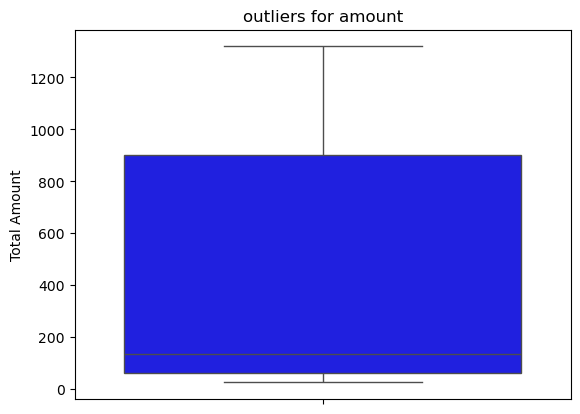

In [106]:
sns.boxplot(df['Total Amount'], color= "blue")
plt.title("outliers for amount")
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_19560\2689503196.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Total Amount'], color='red')


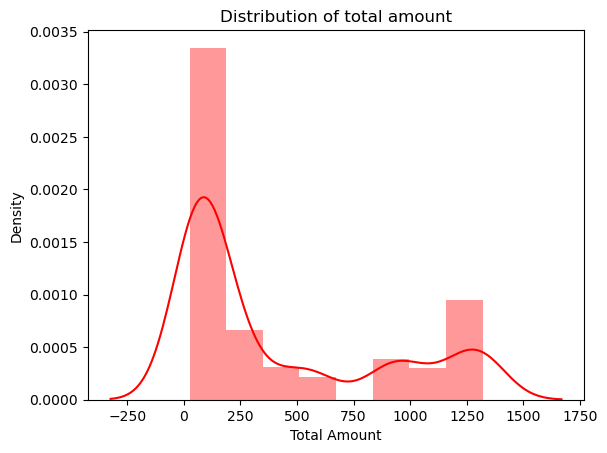

In [109]:
sns.distplot(df['Total Amount'], color='red')
plt.title("Distribution of total amount")
plt.show()

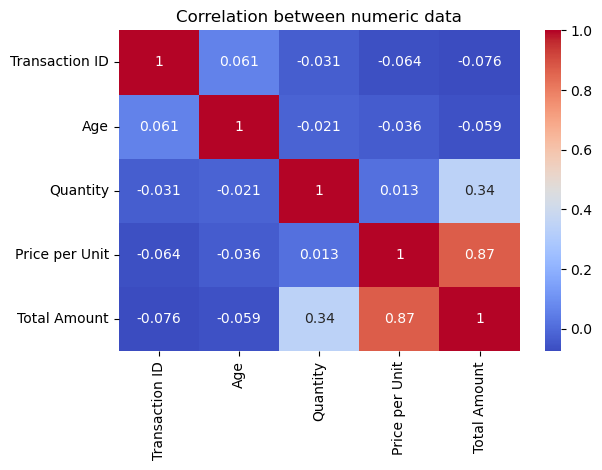

In [112]:
correlatn = df.corr(numeric_only= True)
sns.heatmap(correlatn, annot= True, cmap='coolwarm')
plt.title("Correlation between numeric data")
plt.tight_layout()
plt.show()

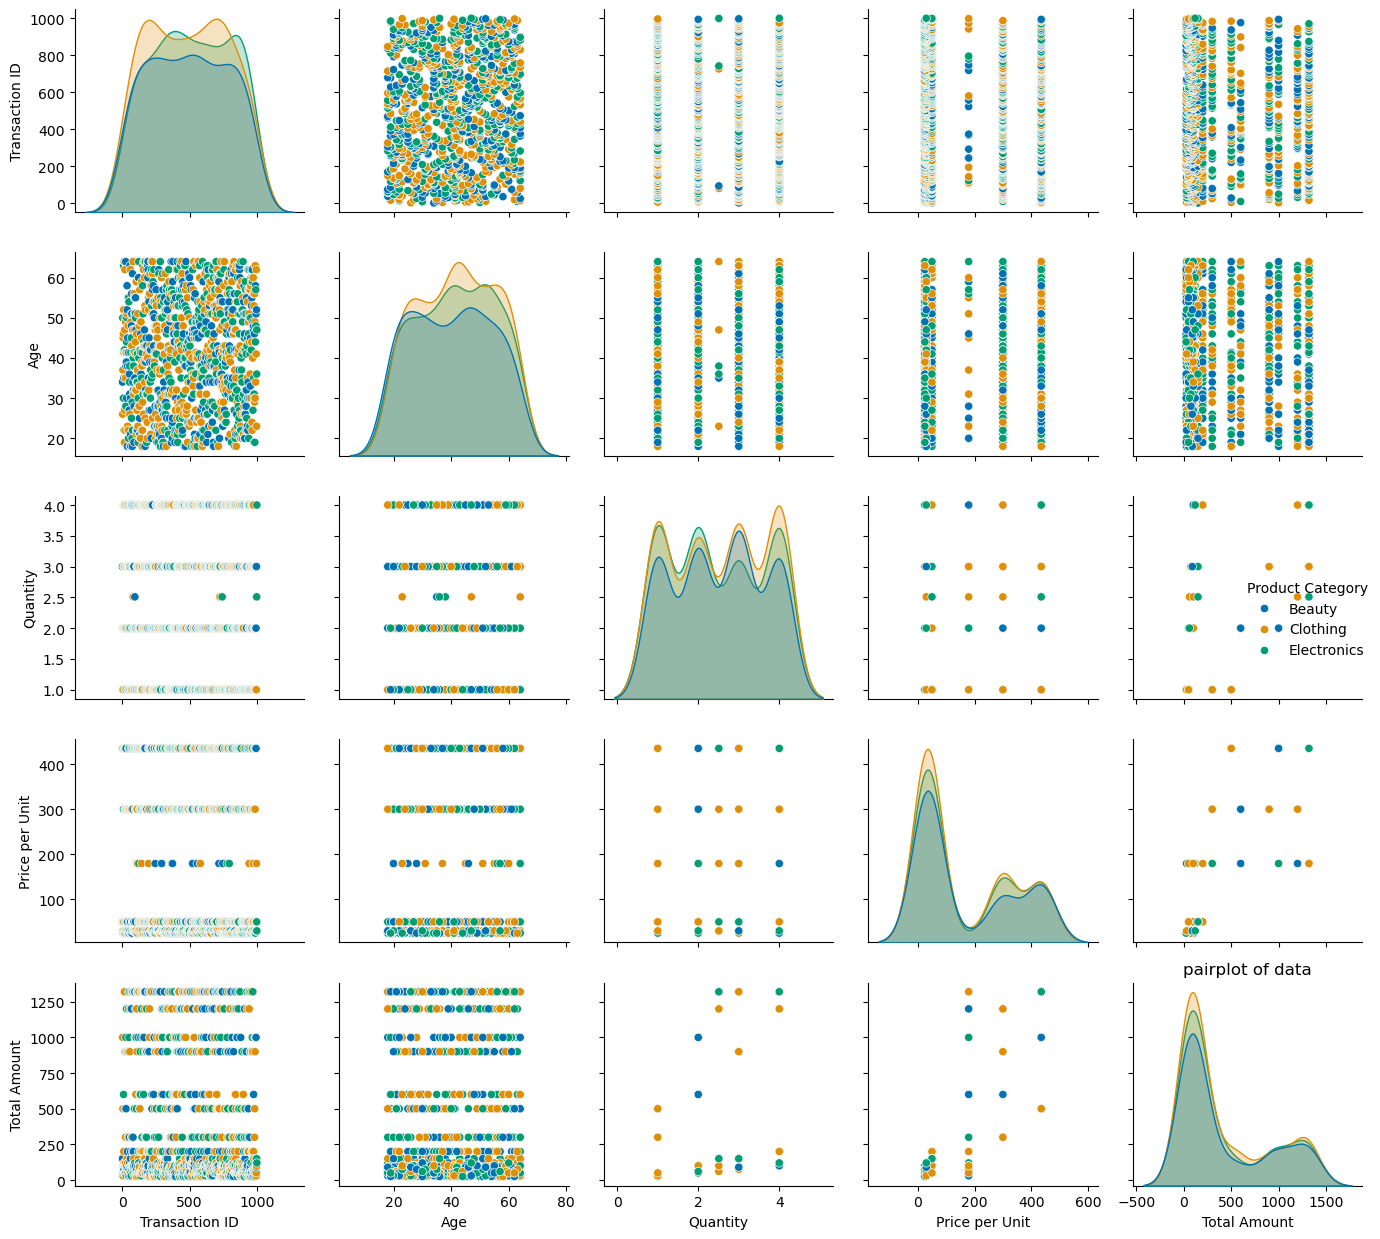

In [114]:
sns.pairplot(df, hue= 'Product Category', palette='colorblind')
plt.title("pairplot of data")
plt.tight_layout()
plt.show()